# Fall Detector — Two-Stream ConvNet (Simonyan & Zisserman, 2014)

Ce notebook reprend l'implémentation two-stream (flux spatial + flux temporel /
flux optique) de *"Two-Stream Convolutional Networks for Action Recognition in
Videos"* appliquée à la détection de chute sur le **Le2i Fall Detection Dataset**.


In [1]:
!pip -q install opencv-python-headless scikit-learn matplotlib --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 100.5 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [ ]:
import os, cv2, glob, random, subprocess, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

FFMPEG_BIN = shutil.which("ffmpeg")
print(f"ffmpeg found at: {FFMPEG_BIN}" if FFMPEG_BIN else
      "WARNING: ffmpeg not found -- video decoding will fall back to cv2.VideoCapture, "
      "which runs in-process and can crash the kernel on a corrupted file.")

CONFIG = {
    "DATA_DIR": "/kaggle/input/falldataset-imvia",  # <-- Le2i dataset path (auto-detected below)
    "LABELS_CSV": "/kaggle/working/labels.csv",

    "L": 10,                          # number of stacked optical-flow frames (paper default)
    "IMG_SIZE": 224,
    "DECODE_SIZE": 256,               # decode a bit larger than IMG_SIZE so we can random-crop
                                       # (paper Sect. 5: rescale so smallest side = 256, then crop 224)
    "MAX_FRAMES": 150,                # cap per video (~6s @ 25fps) -- bounds memory/decode time per sample

    # -- window-aware sampling (the main fix vs v1, see markdown above) --
    "FALL_POST_MARGIN_FRAMES": 15,    # extra frames after annotated fall end still counted as "fall"
                                       # (impact + settling-on-the-ground phase)
    "NEG_MARGIN_FRAMES": 25,          # safety buffer (frames) kept clear around the fall window when
                                       # mining not_fall examples from a fall video
    "TRAIN_SAMPLES_PER_VIDEO": 4,     # how many (pos[+neg]) samples to draw per video, per epoch
    "VAL_SAMPLES_PER_VIDEO": 1,       # one canonical sample per (video, region) in validation
    "VAL_DENSE_K": 5,                 # at eval time, average this many draws per canonical sample

    "BATCH_SIZE": 16,
    "EPOCHS_SPATIAL": 6,
    "EPOCHS_TEMPORAL": 10,
    "EARLY_STOP_PATIENCE": 6,
    "LR": 1e-4,
    "USE_CLASS_WEIGHTS": True,
    "FREEZE_SPATIAL_BACKBONE": False, # set True to fight overfitting further on this small dataset
                                       # (paper Table 1a: "pretrained + last layer" is competitive)

    "NUM_CLASSES": 2,                 # 0 = not_fall, 1 = fall
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
}
print(CONFIG["DEVICE"])

ffmpeg found at: /usr/bin/ffmpeg
cuda


## 1. Construire la liste des vidéos + labels vidéo-niveau

On scanne le dossier, puis on lit le fichier d'annotation
Le2i de chaque vidéo (frame de début/fin de chute, `0,0` = pas de chute). C'est
cette info (`fall_start_frame` / `fall_end_frame`) qu'on va exploiter juste
après pour corriger l'échantillonnage.

In [3]:
def autodetect_data_dir(base="/kaggle/input"):
    """CONFIG['DATA_DIR'] is a guess at the mount path -- Kaggle's exact slug can
    differ. This looks for a 'Coffee_room_01' folder anywhere under /kaggle/input
    and returns its parent, which is the real dataset root."""
    matches = glob.glob(os.path.join(base, "**", "Coffee_room_01"), recursive=True)
    if not matches:
        return None
    shortest = min(matches, key=len)  # outer folder, not the nested duplicate
    return os.path.dirname(shortest)


detected = autodetect_data_dir()
if detected and detected != CONFIG["DATA_DIR"]:
    print(f"CONFIG['DATA_DIR'] was '{CONFIG['DATA_DIR']}' -- auto-detected real path: '{detected}'")
    CONFIG["DATA_DIR"] = detected
elif not detected:
    print("Could not find 'Coffee_room_01' anywhere under /kaggle/input. Contents of /kaggle/input:")
    for entry in sorted(os.listdir("/kaggle/input")):
        print(" -", entry)
    print("Add the dataset via 'Add Input' if it's missing, or set CONFIG['DATA_DIR'] manually above.")


def list_videos(data_dir, exts=(".avi", ".mp4", ".mov", ".mkv")):
    paths = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.lower().endswith(exts):
                paths.append(os.path.join(root, f))
    return paths


videos = list_videos(CONFIG["DATA_DIR"])
print(f"Found {len(videos)} video files")
print(videos[:5])


def find_annotation_file(video_path):
    """
    Le2i ships each video with a matching annotation .txt file:
    first line = fall start frame, second line = fall end frame (0,0 = no fall).
    Some rooms spell the folder "Annotations_files" (with an s) instead of
    "Annotation_files" -- we check both.
    """
    base = os.path.splitext(os.path.basename(video_path))[0]
    video_dir = os.path.dirname(video_path)
    parent = os.path.dirname(video_dir)

    candidates = [os.path.join(video_dir, base + ".txt")]
    for ann_folder in ("Annotation_files", "Annotations_files", "Annotations",
                        "annotation_files", "annotations_files"):
        candidates.append(os.path.join(parent, ann_folder, base + ".txt"))
        candidates.append(os.path.join(video_dir, ann_folder, base + ".txt"))

    for c in candidates:
        if os.path.isfile(c):
            return c
    return None


def label_from_annotation(ann_path):
    """Returns (label, start_frame, end_frame) or None if the file is unreadable."""
    with open(ann_path) as f:
        tokens = f.read().split()
    nums = [int(t) for t in tokens[:2] if t.lstrip("-").isdigit()]
    if len(nums) < 2:
        return None
    start, end = nums[0], nums[1]
    label = 0 if (start == 0 and end == 0) else 1
    return label, start, end


def label_from_path(path):
    """Fallback keyword guess -- only used if no annotation file was found."""
    p = path.lower()
    if any(k in p for k in ["not_fall", "not-fall", "nofall", "adl", "normal", "walking"]):
        return 0
    if "fall" in p:
        return 1
    raise ValueError(f"Could not infer label for: {path}")

CONFIG['DATA_DIR'] was '/kaggle/input/falldataset-imvia' -- auto-detected real path: '/kaggle/input/datasets/tuyenldvn/falldataset-imvia'
Found 190 video files
['/kaggle/input/datasets/tuyenldvn/falldataset-imvia/Lecture_room/Lecture room/video (1).avi', '/kaggle/input/datasets/tuyenldvn/falldataset-imvia/Lecture_room/Lecture room/video (20).avi', '/kaggle/input/datasets/tuyenldvn/falldataset-imvia/Lecture_room/Lecture room/video (11).avi', '/kaggle/input/datasets/tuyenldvn/falldataset-imvia/Lecture_room/Lecture room/video (10).avi', '/kaggle/input/datasets/tuyenldvn/falldataset-imvia/Lecture_room/Lecture room/video (5).avi']


In [4]:
rows = []
n_from_annotation, n_from_fallback, n_skipped = 0, 0, 0

for v in videos:
    ann_path = find_annotation_file(v)
    result = label_from_annotation(ann_path) if ann_path else None

    if result is not None:
        label, start, end = result
        rows.append({"path": v, "label": label, "fall_start_frame": start, "fall_end_frame": end})
        n_from_annotation += 1
        continue

    try:
        rows.append({"path": v, "label": label_from_path(v), "fall_start_frame": None, "fall_end_frame": None})
        n_from_fallback += 1
    except ValueError as e:
        print("SKIP:", e)
        n_skipped += 1

df = pd.DataFrame(rows)
df.to_csv(CONFIG["LABELS_CSV"], index=False)

print(f"Labeled from annotation files: {n_from_annotation}  |  from filename fallback: {n_from_fallback}  |  skipped: {n_skipped}")
print(df["label"].value_counts())
df.head()

Labeled from annotation files: 127  |  from filename fallback: 63  |  skipped: 0
label
1    159
0     31
Name: count, dtype: int64


,path,label,fall_start_frame,fall_end_frame
0,/kaggle/input/datasets/tuyenldvn/falldataset-i...,1,NaN,NaN
1,/kaggle/input/datasets/tuyenldvn/falldataset-i...,1,NaN,NaN
2,/kaggle/input/datasets/tuyenldvn/falldataset-i...,1,NaN,NaN
3,/kaggle/input/datasets/tuyenldvn/falldataset-i...,1,NaN,NaN
4,/kaggle/input/datasets/tuyenldvn/falldataset-i...,1,NaN,NaN


## 2. Visualisation — équilibre des classes (niveau vidéo)

Avant même de parler de modèle : à quoi ressemble le dataset ?

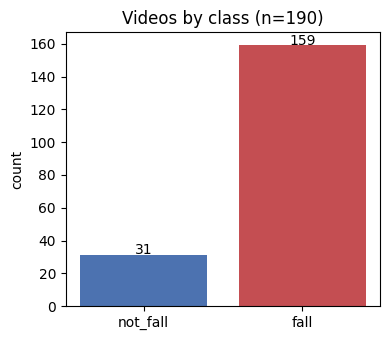

label
1    0.836842
0    0.163158
Name: share, dtype: float64


In [5]:
def plot_class_balance(labels, title, ax=None):
    counts = pd.Series(labels).value_counts().reindex([0, 1]).fillna(0)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4, 3.5))
    bars = ax.bar(["not_fall", "fall"], counts.values, color=["#4C72B0", "#C44E52"])
    for b, c in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, c + 0.5, int(c), ha="center")
    ax.set_title(title)
    ax.set_ylabel("count")
    if own_fig:
        plt.tight_layout(); plt.show()

plot_class_balance(df["label"], f"Videos by class (n={len(df)})")
print(df["label"].value_counts(normalize=True).rename("share"))

## 3. Visualisation — pourquoi tirer une frame au hasard dans toute la

On prend une vidéo "fall" au hasard, on affiche une planche-contact de
frames réparties sur toute sa durée, et on colore le contour en **rouge**
pour les frames qui tombent dans la fenêtre de chute annotée, en **vert**
pour les autres. La majorité des vignettes sont vertes : un tirage aléatoire
uniforme a donc de bonnes chances de retomber sur une frame "normale" tout
en portant l'étiquette "fall" — c'est exactement le bruit décrit plus haut.

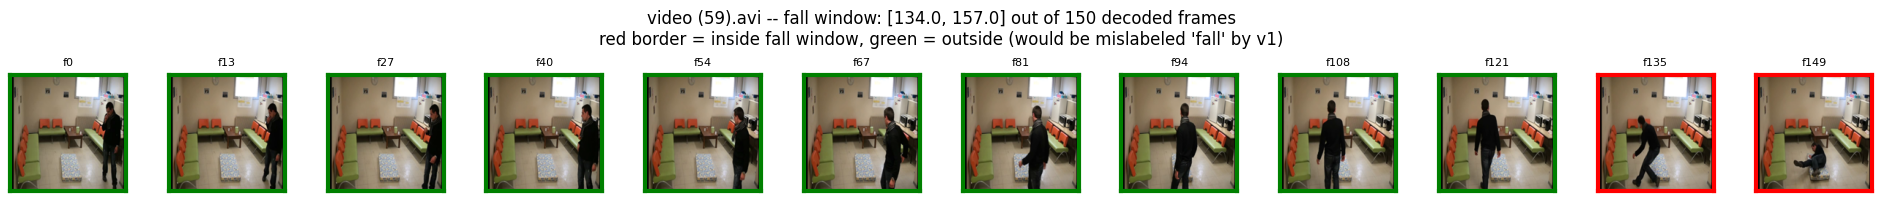

In [6]:
def read_frames_quick(video_path, resize, max_frames):
    """Lightweight ffmpeg-based decode, used only for quick visualisations in
    this section (the real read_frames() with full crash-safety is defined below)."""
    w, h = resize
    if not FFMPEG_BIN:
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(cv2.resize(frame, (w, h)))
        cap.release()
        return frames
    cmd = [FFMPEG_BIN, "-v", "error", "-i", video_path, "-frames:v", str(max_frames),
           "-vf", f"scale={w}:{h}", "-pix_fmt", "rgb24", "-f", "rawvideo", "-"]
    result = subprocess.run(cmd, capture_output=True, timeout=60)
    if result.returncode != 0 or not result.stdout:
        return []
    frame_size = w * h * 3
    raw = result.stdout
    n = len(raw) // frame_size
    return [np.frombuffer(raw[i*frame_size:(i+1)*frame_size], dtype=np.uint8).reshape(h, w, 3).copy()
            for i in range(n)]


def plot_fall_timeline(row, n_thumbs=12, decode_size=160):
    frames = read_frames_quick(row["path"], (decode_size, decode_size), CONFIG["MAX_FRAMES"])
    n = len(frames)
    if n == 0:
        print("Could not decode", row["path"]); return
    start, end = row["fall_start_frame"], row["fall_end_frame"]
    idxs = np.linspace(0, n - 1, min(n_thumbs, n)).astype(int)

    fig, axes = plt.subplots(1, len(idxs), figsize=(1.6 * len(idxs), 2))
    for ax, i in zip(axes, idxs):
        in_window = start is not None and start <= i <= end
        ax.imshow(frames[i])
        color = "red" if in_window else "green"
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(3)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"f{i}", fontsize=8)
    fig.suptitle(f"{os.path.basename(row['path'])} -- fall window: [{start}, {end}] out of {n} decoded frames\n"
                 f"red border = inside fall window, green = outside (would be mislabeled 'fall' by v1)")
    plt.tight_layout(); plt.show()


sample_fall_row = df[(df["label"] == 1) & (df["fall_start_frame"].notna()) & (df["fall_start_frame"] > 0)].iloc[0]
plot_fall_timeline(sample_fall_row)

## 4. Décodage vidéo + flux optique (papier Sect. 3.1)

- `read_frames` décode une vidéo en frames RGB, via **ffmpeg en sous-processus**
  (une vidéo corrompue ne peut donc pas faire planter le kernel Jupyter).
- `compute_flow_stack` implémente l'**Eq. (1)** du papier : empile les
  composantes horizontale/verticale de `L` flux optiques consécutifs en un
  volume `(2L, H, W)`, avec **soustraction de la moyenne du flux** (Sect. 3.1,
  *"Mean flow subtraction"*) pour annuler un biais de mouvement de caméra.
- On utilise l'algorithme dense de Farneback (OpenCV). Le papier original
  utilise celui de Brox et al., indisponible dans OpenCV standard ; Farneback
  est le substitut open-source usuel pour reproduire cette architecture.
- `flow_to_color` sert uniquement à la **visualisation** 
 

In [7]:
def read_frames(video_path, resize, max_frames=None, timeout=60):
    """Decodes up to max_frames RGB frames, resized to `resize` = (w, h).

    Runs ffmpeg as a SEPARATE OS process when available, so a corrupted file can only
    crash that subprocess -- never the Jupyter kernel itself. Falls back to
    cv2.VideoCapture only if ffmpeg isn't installed on this image.
    """
    max_frames = max_frames or CONFIG.get("MAX_FRAMES", 150)
    w, h = resize

    if FFMPEG_BIN:
        cmd = [
            FFMPEG_BIN, "-v", "error", "-i", video_path,
            "-frames:v", str(max_frames),
            "-vf", f"scale={w}:{h}",
            "-pix_fmt", "rgb24", "-f", "rawvideo", "-",
        ]
        try:
            result = subprocess.run(cmd, capture_output=True, timeout=timeout)
        except subprocess.TimeoutExpired:
            return []
        if result.returncode != 0 or not result.stdout:
            return []
        frame_size = w * h * 3
        raw = result.stdout
        n_frames = len(raw) // frame_size
        return [
            np.frombuffer(raw[i * frame_size:(i + 1) * frame_size], dtype=np.uint8)
              .reshape(h, w, 3).copy()
            for i in range(n_frames)
        ]

    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (w, h))
        frames.append(frame)
    cap.release()
    return frames


def compute_flow_stack(frames, start_idx, L, size, mean_subtract=True):
    """Eq. (1): stack d_x, d_y of L consecutive frame pairs -> (2L, H, W)."""
    gray = [cv2.cvtColor(cv2.resize(f, size), cv2.COLOR_RGB2GRAY)
            for f in frames[start_idx:start_idx + L + 1]]

    channels = []
    for k in range(L):
        flow = cv2.calcOpticalFlowFarneback(
            gray[k], gray[k + 1], None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0,
        )
        dx, dy = flow[..., 0], flow[..., 1]
        if mean_subtract:
            dx = dx - dx.mean()
            dy = dy - dy.mean()
        channels.append(dx)
        channels.append(dy)

    stack = np.stack(channels, axis=0)            # (2L, H, W)
    stack = np.clip(stack / 20.0, -1, 1)           # rough normalisation to [-1, 1]
    return stack.astype(np.float32)


def flow_to_color(dx, dy):
    """HSV colour-wheel visualisation of a flow field: hue = direction,
    value = magnitude. For display only (cf. paper Fig. 2c)."""
    mag, ang = cv2.cartToPolar(dx.astype(np.float32), dy.astype(np.float32))
    hsv = np.zeros((*dx.shape, 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag * 8, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

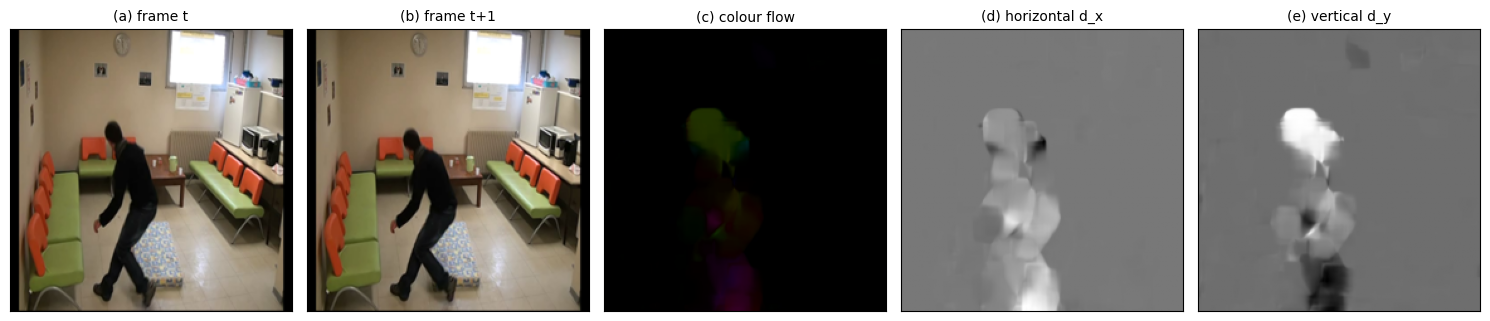

In [8]:
def show_flow_demo(video_path, frame_idx=None, size=224):
    """Recreates paper Figure 2 (a,b,c,d,e): two consecutive frames, colour flow,
    dx heatmap, dy heatmap."""
    frames = read_frames_quick(video_path, (size, size), CONFIG["MAX_FRAMES"])
    if len(frames) < 2:
        print("Could not decode enough frames from", video_path); return
    if frame_idx is None:
        frame_idx = random.randint(0, len(frames) - 2)
    frame_idx = min(frame_idx, len(frames) - 2)

    g1 = cv2.cvtColor(frames[frame_idx], cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(frames[frame_idx + 1], cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(g1, g2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    dx, dy = flow[..., 0], flow[..., 1]

    panels = [
        (frames[frame_idx], "(a) frame t"),
        (frames[frame_idx + 1], "(b) frame t+1"),
        (flow_to_color(dx, dy), "(c) colour flow"),
        (dx, "(d) horizontal d_x"),
        (dy, "(e) vertical d_y"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
    for ax, (img, title) in zip(axes, panels):
        cmap = "gray" if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()


# Demo on the fall video used above, right around its fall window (interesting motion)
demo_idx = int(sample_fall_row["fall_start_frame"]) if sample_fall_row["fall_start_frame"] else None
show_flow_demo(sample_fall_row["path"], frame_idx=demo_idx)

### Visualiser le stack complet de `L` flux (ce que voit réellement le réseau temporel)

Le réseau temporel ne reçoit pas une image "flux couleur" comme ci-dessus,
mais **20 canaux bruts** (`2 x L=10`) de `d_x`/`d_y`. Voici à quoi ça ressemble
une fois assemblé -- proche de la mise en page de la Figure 4 du papier.

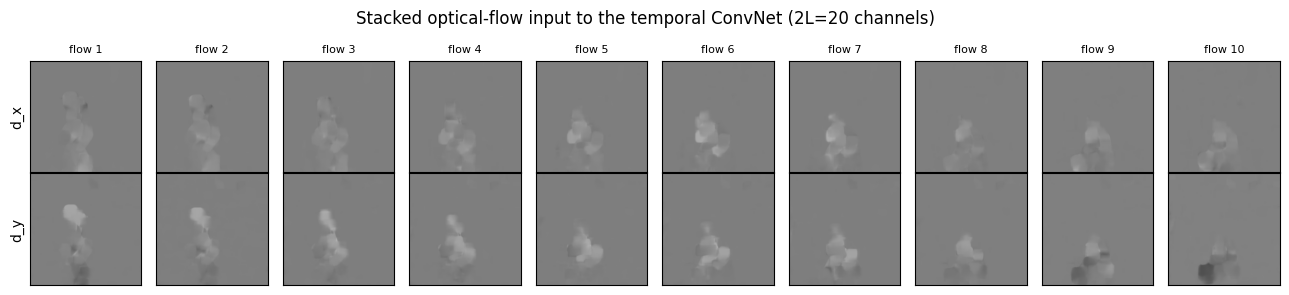

In [9]:
def show_flow_stack_grid(flow_stack, max_k=10):
    """flow_stack: (2L, H, W) array as produced by compute_flow_stack. Displays
    dx_k on row 0 and dy_k on row 1, one column per stacked frame k (cf. paper
    Fig. 3/4 layout)."""
    L = flow_stack.shape[0] // 2
    k_show = min(max_k, L)
    fig, axes = plt.subplots(2, k_show, figsize=(1.3 * k_show, 3))
    for k in range(k_show):
        axes[0, k].imshow(flow_stack[2 * k], cmap="gray", vmin=-1, vmax=1)
        axes[1, k].imshow(flow_stack[2 * k + 1], cmap="gray", vmin=-1, vmax=1)
        axes[0, k].set_xticks([]); axes[0, k].set_yticks([])
        axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
        axes[0, k].set_title(f"flow {k+1}", fontsize=8)
    axes[0, 0].set_ylabel("d_x", fontsize=10)
    axes[1, 0].set_ylabel("d_y", fontsize=10)
    fig.suptitle(f"Stacked optical-flow input to the temporal ConvNet (2L={2*L} channels)")
    plt.tight_layout(); plt.show()


demo_frames = read_frames_quick(sample_fall_row["path"], (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]), CONFIG["MAX_FRAMES"])
start = int(sample_fall_row["fall_start_frame"]) if sample_fall_row["fall_start_frame"] else 0
start = min(start, max(0, len(demo_frames) - CONFIG["L"] - 1))
demo_stack = compute_flow_stack(demo_frames, start, CONFIG["L"], (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))
show_flow_stack_grid(demo_stack)

## 5. Valider les vidéos


In [10]:
print(f"Validating {len(df)} videos (same decode path as training)...")
bad_videos = []
for i, p in enumerate(df["path"]):
    frames = read_frames(p, resize=(CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]), max_frames=CONFIG["L"] + 1)
    if len(frames) < CONFIG["L"] + 1:
        bad_videos.append(p)
    if (i + 1) % 25 == 0:
        print(f"  checked {i + 1}/{len(df)}...")

if bad_videos:
    print(f"Dropping {len(bad_videos)} unreadable/corrupted video(s):")
    for p in bad_videos:
        print(" -", p)
    df = df[~df["path"].isin(bad_videos)].reset_index(drop=True)
    df.to_csv(CONFIG["LABELS_CSV"], index=False)
else:
    print("All videos decoded cleanly -- nothing dropped.")

print(f"{len(df)} usable videos remain.")
df["label"].value_counts()

Validating 190 videos (same decode path as training)...
  checked 25/190...
  checked 50/190...
  checked 75/190...
  checked 100/190...
  checked 125/190...
  checked 150/190...
  checked 175/190...
All videos decoded cleanly -- nothing dropped.
190 usable videos remain.


label
1    159
0     31
Name: count, dtype: int64

## 6. Construire un index d'échantillons niveau *frame*



In [11]:
def get_fall_window(row, post_margin=0):
    """Returns (start, end) frame indices of the annotated fall event, or None
    if this video has no fall window (pure ADL video, or missing/unusable
    annotation)."""
    s, e = row.get("fall_start_frame"), row.get("fall_end_frame")
    if s is None or e is None or pd.isna(s) or pd.isna(e):
        return None
    s, e = int(s), int(e)
    if s == 0 and e == 0:
        return None
    return s, e + post_margin


def build_sample_index(video_df, samples_per_video, neg_margin_frames, post_margin_frames):
    """Expands a video-level dataframe into a sample-level index (see markdown above)."""
    rows = []
    for _, r in video_df.iterrows():
        window = get_fall_window(r, post_margin=post_margin_frames)
        if window is None:
            for _ in range(samples_per_video):
                rows.append({"path": r["path"], "label": 0, "window": None, "margin": 0})
        else:
            for _ in range(samples_per_video):
                rows.append({"path": r["path"], "label": 1, "window": window, "margin": 0})
            for _ in range(samples_per_video):
                rows.append({"path": r["path"], "label": 0, "window": window, "margin": neg_margin_frames})
    return pd.DataFrame(rows)


def pick_frame_start(n_frames, window, margin, label, need):
    """Chooses a valid start index for a sample of `need` consecutive frames
    (need=1 for a single spatial frame, need=L+1 for a temporal flow stack),
    respecting the region assigned by build_sample_index.

    Both `start` and `end` are clipped to the decoded frame range: the
    annotation file gives frame numbers on the FULL video, but `n_frames`
    here is however many frames read_frames() actually decoded (capped by
    MAX_FRAMES). Without clipping BOTH ends, a video longer than MAX_FRAMES
    whose fall window falls after the decode cutoff produces out-of-range
    candidate indices in the not_fall search zones below -> IndexError."""
    max_start = max(0, n_frames - need)
    if window is None:
        return random.randint(0, max_start) if max_start > 0 else 0

    start, end = window
    start = max(0, min(start, n_frames - 1))
    end = max(0, min(end, n_frames - 1))
    if label == 1:
        lo, hi = start, max(start, min(end, max_start))
        return random.randint(lo, hi) if hi > lo else min(lo, max_start)

    lo_zone = list(range(0, max(0, start - margin - need + 1)))
    hi_zone = list(range(min(n_frames, end + margin + 1), max_start + 1))
    candidates = lo_zone + hi_zone
    if candidates:
        return random.choice(candidates)
    return random.randint(0, max_start) if max_start > 0 else 0

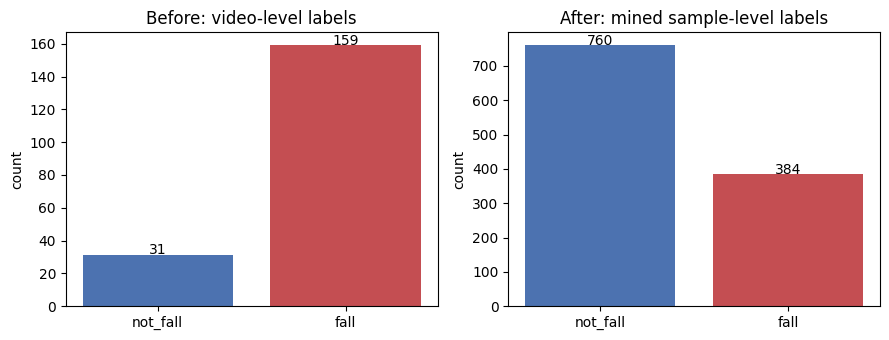

label
0    760
1    384
Name: count, dtype: int64


In [12]:
preview_samples = build_sample_index(df, samples_per_video=CONFIG["TRAIN_SAMPLES_PER_VIDEO"],
                                      neg_margin_frames=CONFIG["NEG_MARGIN_FRAMES"],
                                      post_margin_frames=CONFIG["FALL_POST_MARGIN_FRAMES"])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_class_balance(df["label"], "Before: video-level labels", ax=axes[0])
plot_class_balance(preview_samples["label"], "After: mined sample-level labels", ax=axes[1])
plt.tight_layout(); plt.show()

print(preview_samples["label"].value_counts())

## 7. Datasets PyTorch

- `SpatialFallDataset` renvoie une frame RGB (normalisée ImageNet) tirée dans
  la bonne région (flux spatial).
- `TemporalFallDataset` renvoie un stack de flux `(2L, H, W)` tiré dans la
  bonne région (flux temporel).
- Les deux appliquent une **augmentation légère** en entraînement : crop
  aléatoire (décodage à `DECODE_SIZE`, crop à `IMG_SIZE`) + flip horizontal.
  Pour le flux temporel, un flip horizontal doit **inverser le signe de la
  composante `d_x`** du flux (miroir du mouvement), sinon on introduirait un
  signal incohérent.


In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

spatial_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def random_or_center_crop(frame, size, augment):
    h, w = frame.shape[:2]
    if h == size and w == size:
        return frame
    max_y, max_x = max(0, h - size), max(0, w - size)
    if augment:
        y, x = random.randint(0, max_y), random.randint(0, max_x)
    else:
        y, x = max_y // 2, max_x // 2
    return frame[y:y + size, x:x + size]


class SpatialFallDataset(Dataset):
    def __init__(self, samples_df, img_size, decode_size, augment):
        self.df = samples_df.reset_index(drop=True)
        self.img_size = img_size
        self.decode_size = decode_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load(self, row):
        frames = read_frames(row["path"], resize=(self.decode_size, self.decode_size),
                              max_frames=CONFIG["MAX_FRAMES"])
        if len(frames) == 0:
            raise ValueError("no frames decoded")
        idx = pick_frame_start(len(frames), row["window"], row["margin"], row["label"], need=1)
        frame = random_or_center_crop(frames[idx], self.img_size, self.augment)
        if self.augment and random.random() < 0.5:
            frame = frame[:, ::-1, :].copy()
        return spatial_transform(frame), row["label"]

    def __getitem__(self, idx, _retries=3):
        row = self.df.iloc[idx]
        try:
            return self._load(row)
        except Exception:
            if _retries <= 0:
                blank = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
                return spatial_transform(blank), row["label"]
            return self.__getitem__(random.randint(0, len(self.df) - 1), _retries=_retries - 1)


class TemporalFallDataset(Dataset):
    def __init__(self, samples_df, L, img_size, decode_size, augment):
        self.df = samples_df.reset_index(drop=True)
        self.L = L
        self.img_size = img_size
        self.decode_size = decode_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load(self, row):
        need = self.L + 1
        frames = read_frames(row["path"], resize=(self.decode_size, self.decode_size),
                              max_frames=CONFIG["MAX_FRAMES"])
        pad_tries = 0
        while len(frames) < need and pad_tries < 10:
            frames = frames + frames
            pad_tries += 1
        if len(frames) < need:
            raise ValueError("clip too short even after padding")

        start = pick_frame_start(len(frames), row["window"], row["margin"], row["label"], need=need)

        if self.augment:
            y = random.randint(0, self.decode_size - self.img_size)
            x = random.randint(0, self.decode_size - self.img_size)
            clip = [f[y:y + self.img_size, x:x + self.img_size] for f in frames[start:start + need]]
        else:
            clip = [random_or_center_crop(f, self.img_size, False) for f in frames[start:start + need]]

        flip = self.augment and random.random() < 0.5
        if flip:
            clip = [f[:, ::-1, :].copy() for f in clip]

        flow_stack = compute_flow_stack(clip, 0, self.L, (self.img_size, self.img_size))
        if flip:
            flow_stack[0::2] *= -1  # mirror flips motion direction -> negate d_x channels
        return torch.from_numpy(flow_stack), row["label"]

    def __getitem__(self, idx, _retries=3):
        row = self.df.iloc[idx]
        try:
            return self._load(row)
        except Exception:
            if _retries <= 0:
                blank = np.zeros((2 * self.L, self.img_size, self.img_size), dtype=np.float32)
                return torch.from_numpy(blank), row["label"]
            return self.__getitem__(random.randint(0, len(self.df) - 1), _retries=_retries - 1)

label: 1 -- flow stack shape: (20, 224, 224)


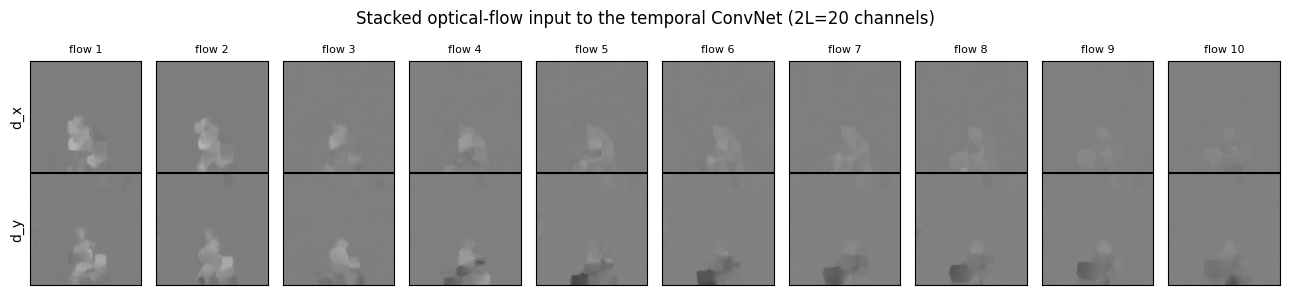

In [14]:
# Sanity-check visual: pull one temporal sample through the real Dataset (with
# augmentation) and display its flow stack, same viewer as section 4.
_demo_ds = TemporalFallDataset(preview_samples[preview_samples["label"] == 1].iloc[:1],
                                CONFIG["L"], CONFIG["IMG_SIZE"], CONFIG["DECODE_SIZE"], augment=True)
_x, _y = _demo_ds[0]
print("label:", _y, "-- flow stack shape:", tuple(_x.shape))
show_flow_stack_grid(_x.numpy())

## 8. Split train/val 

Important : on sépare d'abord les *vidéos* en train/val (stratifié sur le
label vidéo), **puis** on construit les échantillons de chaque côté
séparément. Si on construisait l'index d'échantillons avant de splitter, des
frames de la même vidéo pourraient se retrouver à la fois en train et en val
(fuite de données)

Pour la validation, `VAL_SAMPLES_PER_VIDEO=1` donne un échantillon canonique
par (vidéo, région) ; l'évaluation "dense" plus bas moyennera plusieurs
tirages *à l'intérieur* de cette région pour réduire la variance, sans jamais
mélanger train et val.

In [15]:
train_videos_df, val_videos_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
print(len(train_videos_df), "train videos /", len(val_videos_df), "val videos")

train_samples_df = build_sample_index(
    train_videos_df, samples_per_video=CONFIG["TRAIN_SAMPLES_PER_VIDEO"],
    neg_margin_frames=CONFIG["NEG_MARGIN_FRAMES"], post_margin_frames=CONFIG["FALL_POST_MARGIN_FRAMES"],
)
val_samples_df = build_sample_index(
    val_videos_df, samples_per_video=CONFIG["VAL_SAMPLES_PER_VIDEO"],
    neg_margin_frames=CONFIG["NEG_MARGIN_FRAMES"], post_margin_frames=CONFIG["FALL_POST_MARGIN_FRAMES"],
)

print(f"train samples: {len(train_samples_df)}  ({train_samples_df['label'].value_counts().to_dict()})")
print(f"val samples:   {len(val_samples_df)}  ({val_samples_df['label'].value_counts().to_dict()})")

152 train videos / 38 val videos
train samples: 928  ({0: 608, 1: 320})
val samples:   54  ({0: 38, 1: 16})


## 9. Modèles

- **Flux spatial** : ResNet-18 pré-entraîné ImageNet, dernière couche
  remplacée pour la classification binaire (papier Sect. 2 et 5). `Dropout`
  ajouté avant la couche finale pour limiter le sur-apprentissage sur un
  dataset aussi petit. `FREEZE_SPATIAL_BACKBONE=True` (dans `CONFIG`) permet
  de ne ré-entraîner que la tête, comme la config "pretrained + last layer"
  du Tableau 1a du papier, qui était compétitive.
- **Flux temporel** : même backbone, mais `conv1` accepte `2L` canaux au lieu
  de 3. On utilise l'*initialisation cross-modality* (moyenne des filtres RGB
  pré-entraînés, répliquée sur les `2L` canaux) plutôt que l'entraînement
  100% from-scratch du papier — ça converge mieux sur un aussi petit dataset.

In [16]:
def _load_resnet18(pretrained):
    """Tries to download ImageNet weights; falls back to random init if Kaggle's
    internet is off (Settings -> Internet -> On). Returns (model, got_pretrained)."""
    if not pretrained:
        return models.resnet18(weights=None), False
    try:
        return models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1), True
    except Exception as e:
        print(f"Could not download ImageNet weights ({e}).")
        print("Fix: Kaggle notebook Settings (right panel) -> Internet -> On, then rerun this cell.")
        print("Continuing with randomly-initialized weights for now so the pipeline doesn't block.")
        return models.resnet18(weights=None), False


def build_spatial_model(num_classes, freeze_backbone=False, dropout=0.5):
    model, _ = _load_resnet18(pretrained=True)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(model.fc.in_features, num_classes))
    return model


def build_temporal_model(num_classes, in_channels, cross_modality_init=True, dropout=0.5):
    model, got_pretrained = _load_resnet18(pretrained=cross_modality_init)
    do_cross_modality_init = cross_modality_init and got_pretrained

    old_conv = model.conv1
    new_conv = nn.Conv2d(
        in_channels, old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=False,
    )
    if do_cross_modality_init:
        with torch.no_grad():
            avg_w = old_conv.weight.mean(dim=1, keepdim=True)          # (out,1,k,k)
            new_conv.weight.copy_(avg_w.repeat(1, in_channels, 1, 1))
    model.conv1 = new_conv
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(model.fc.in_features, num_classes))
    return model

## 10. Boucle d'entraînement (partagée par les deux flux)

- **pondération de classes** dans la loss (calculée depuis `train_samples_df`) ;
- le **meilleur checkpoint** est choisi sur le **F1 macro de validation**
  (plus informatif que l'accuracy brute vu le déséquilibre), et on garde
  l'historique complet pour tracer les courbes ;
- **arrêt anticipé** si le F1 macro de validation ne progresse plus pendant
  `EARLY_STOP_PATIENCE` époques.

In [17]:
def compute_class_weights(labels, num_classes=2):
    counts = pd.Series(labels).value_counts().reindex(range(num_classes)).fillna(1)
    weights = counts.sum() / (num_classes * counts)
    return weights.values.astype(np.float32)


def train_model(model, train_loader, val_loader, epochs, lr, device, tag,
                 class_weights=None, patience=CONFIG["EARLY_STOP_PATIENCE"]):
    model = model.to(device)
    weight = torch.tensor(class_weights).to(device) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weight)
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
    best_f1, epochs_no_improve = 0.0, 0
    ckpt_path = f"/kaggle/working/best_{tag}.pt"

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                out = model(x)
                y_pred.extend(out.argmax(1).cpu().tolist())
                y_true.extend(y.tolist())
        val_acc = sum(int(p == t) for p, t in zip(y_pred, y_true)) / max(1, len(y_true))
        val_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) if y_true else 0.0
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"[{tag}] epoch {epoch+1}/{epochs} - loss {train_loss:.4f} "
              f"- train_acc {train_acc:.4f} - val_acc {val_acc:.4f} - val_macro_f1 {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1, epochs_no_improve = val_f1, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{tag}] early stopping (no val macro-F1 improvement for {patience} epochs)")
                break

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history


def plot_history(history, tag):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].set_title(f"{tag}: training loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="train acc")
    axes[1].plot(history["val_acc"], label="val acc")
    axes[1].plot(history["val_f1"], label="val macro-F1", linestyle="--")
    axes[1].set_title(f"{tag}: accuracy / F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

## 11. Entraîner le flux spatial

class weights: [0.7631579 1.45     ]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s] 


[spatial] epoch 1/20 - loss 0.5814 - train_acc 0.6886 - val_acc 0.7222 - val_macro_f1 0.7051
[spatial] epoch 2/20 - loss 0.3657 - train_acc 0.8297 - val_acc 0.8519 - val_macro_f1 0.8224
[spatial] epoch 3/20 - loss 0.3201 - train_acc 0.8610 - val_acc 0.7963 - val_macro_f1 0.7675
[spatial] epoch 4/20 - loss 0.2347 - train_acc 0.9019 - val_acc 0.8889 - val_macro_f1 0.8615
[spatial] epoch 5/20 - loss 0.2125 - train_acc 0.9062 - val_acc 0.8333 - val_macro_f1 0.7879
[spatial] epoch 6/20 - loss 0.1811 - train_acc 0.9192 - val_acc 0.8148 - val_macro_f1 0.7692
[spatial] epoch 7/20 - loss 0.1518 - train_acc 0.9278 - val_acc 0.8333 - val_macro_f1 0.8036
[spatial] epoch 8/20 - loss 0.1301 - train_acc 0.9494 - val_acc 0.8519 - val_macro_f1 0.8224
[spatial] epoch 9/20 - loss 0.1163 - train_acc 0.9601 - val_acc 0.8704 - val_macro_f1 0.8350
[spatial] epoch 10/20 - loss 0.1187 - train_acc 0.9494 - val_acc 0.8148 - val_macro_f1 0.7692
[spatial] early stopping (no val macro-F1 improvement for 6 epochs)


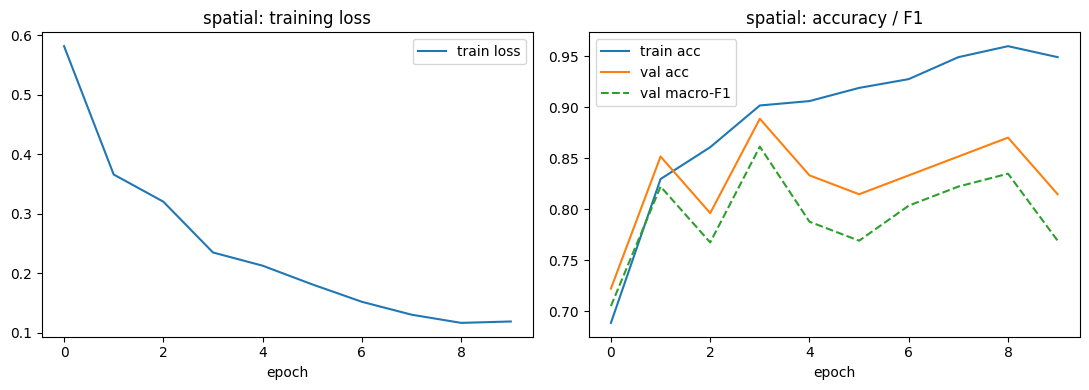

In [18]:
train_spatial_ds = SpatialFallDataset(train_samples_df, CONFIG["IMG_SIZE"], CONFIG["DECODE_SIZE"], augment=True)
val_spatial_ds = SpatialFallDataset(val_samples_df, CONFIG["IMG_SIZE"], CONFIG["DECODE_SIZE"], augment=False)

train_spatial_loader = DataLoader(train_spatial_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=0)
val_spatial_loader = DataLoader(val_spatial_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=0)

spatial_class_weights = compute_class_weights(train_samples_df["label"]) if CONFIG["USE_CLASS_WEIGHTS"] else None
print("class weights:", spatial_class_weights)

spatial_model = build_spatial_model(CONFIG["NUM_CLASSES"], freeze_backbone=CONFIG["FREEZE_SPATIAL_BACKBONE"])
spatial_model, spatial_history = train_model(
    spatial_model, train_spatial_loader, val_spatial_loader,
    CONFIG["EPOCHS_SPATIAL"], CONFIG["LR"], CONFIG["DEVICE"], tag="spatial",
    class_weights=spatial_class_weights,
)
plot_history(spatial_history, "spatial")

## 12. Entraîner le flux temporel (flux optique)

[temporal] epoch 1/30 - loss 0.5238 - train_acc 0.7500 - val_acc 0.7593 - val_macro_f1 0.6617
[temporal] epoch 2/30 - loss 0.3086 - train_acc 0.8610 - val_acc 0.8704 - val_macro_f1 0.8473
[temporal] epoch 3/30 - loss 0.2644 - train_acc 0.8901 - val_acc 0.8333 - val_macro_f1 0.8150
[temporal] epoch 4/30 - loss 0.2213 - train_acc 0.9127 - val_acc 0.8519 - val_macro_f1 0.8071
[temporal] epoch 5/30 - loss 0.1810 - train_acc 0.9278 - val_acc 0.7963 - val_macro_f1 0.7407
[temporal] epoch 6/30 - loss 0.1518 - train_acc 0.9321 - val_acc 0.8333 - val_macro_f1 0.7778
[temporal] epoch 7/30 - loss 0.1157 - train_acc 0.9483 - val_acc 0.8519 - val_macro_f1 0.7974
[temporal] epoch 8/30 - loss 0.0895 - train_acc 0.9688 - val_acc 0.8333 - val_macro_f1 0.7778
[temporal] early stopping (no val macro-F1 improvement for 6 epochs)


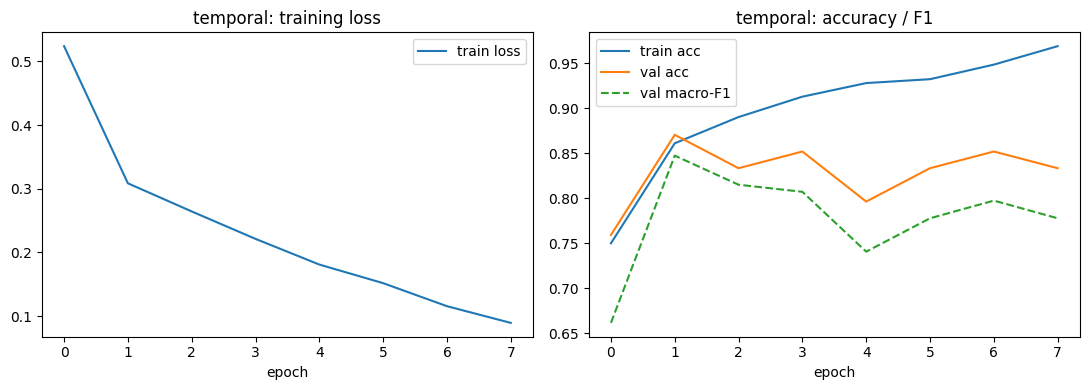

In [22]:
train_temporal_ds = TemporalFallDataset(train_samples_df, CONFIG["L"], CONFIG["IMG_SIZE"], CONFIG["DECODE_SIZE"], augment=True)
val_temporal_ds = TemporalFallDataset(val_samples_df, CONFIG["L"], CONFIG["IMG_SIZE"], CONFIG["DECODE_SIZE"], augment=False)

train_temporal_loader = DataLoader(train_temporal_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=0)
val_temporal_loader = DataLoader(val_temporal_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=0)

temporal_class_weights = compute_class_weights(train_samples_df["label"]) if CONFIG["USE_CLASS_WEIGHTS"] else None

temporal_model = build_temporal_model(CONFIG["NUM_CLASSES"], in_channels=2 * CONFIG["L"])
temporal_model, temporal_history = train_model(
    temporal_model, train_temporal_loader, val_temporal_loader,
    CONFIG["EPOCHS_TEMPORAL"], CONFIG["LR"], CONFIG["DEVICE"], tag="temporal",
    class_weights=temporal_class_weights,
)
plot_history(temporal_history, "temporal")

## 13. Visualiser les filtres appris (1ère couche du flux temporel)

Comparable à la Figure 4 du papier : chaque colonne est un filtre `7x7` de
`conv1`, on affiche ici sa réponse sur les canaux `d_x`/`d_y` du **premier**
flux empilé (canaux 0 et 1 sur les `2L` disponibles).

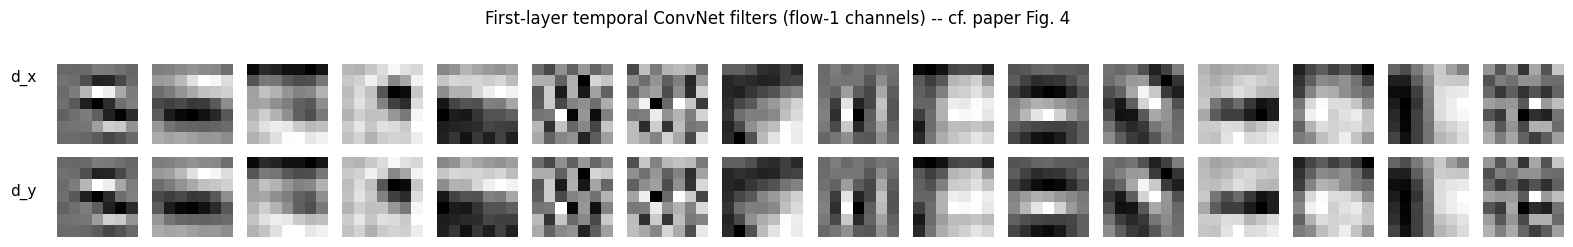

In [24]:
def visualize_temporal_filters(model, n_show=16):
    w = model.conv1.weight.detach().cpu().numpy()  # (out_channels, in_channels=2L, k, k)
    n_show = min(n_show, w.shape[0])
    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.0, 2.6))
    for i in range(n_show):
        axes[0, i].imshow(w[i, 0], cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(w[i, 1], cmap="gray"); axes[1, i].axis("off")
    fig.text(0.02, 0.72, "d_x", fontsize=11, va="center")
    fig.text(0.02, 0.28, "d_y", fontsize=11, va="center")
    fig.suptitle("First-layer temporal ConvNet filters (flow-1 channels) -- cf. paper Fig. 4")
    plt.tight_layout(rect=[0.04, 0, 1, 1]); plt.show()

visualize_temporal_filters(temporal_model)

## 14. Évaluation deux-flux — fusion tardive, "dense" comme le papier

Fusion tardive (papier Sect. 2) : on moyenne les scores softmax des deux flux.
Comme le papier moyenne les prédictions sur plusieurs frames/crops par vidéo
en test (Sect. 5, *Testing*), on moyenne ici les prédictions sur `VAL_DENSE_K`
tirages **dans la région assignée** à chaque échantillon de validation, pour
réduire la variance d'une évaluation sur un aussi petit dataset.

              precision    recall  f1-score   support

    not_fall       0.90      0.92      0.91        38
        fall       0.80      0.75      0.77        16

    accuracy                           0.87        54
   macro avg       0.85      0.84      0.84        54
weighted avg       0.87      0.87      0.87        54

[[35  3]
 [ 4 12]]


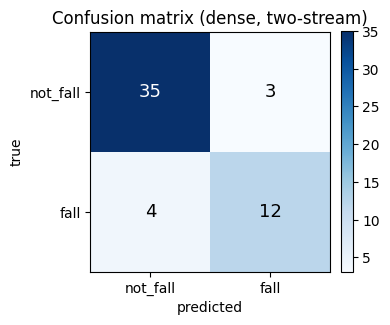

In [26]:
@torch.no_grad()
def dense_predict_one(row, spatial_model, temporal_model, config, k):
    # Wrapped defensively: falls back to a neutral 0.5/0.5 prediction for any
    # one sample that hits an unforeseen edge case, instead of crashing the
    # whole evaluation loop (same spirit as the retry logic in the Datasets).
    device = config["DEVICE"]
    try:
        frames = read_frames(row["path"], resize=(config["DECODE_SIZE"], config["DECODE_SIZE"]),
                              max_frames=config["MAX_FRAMES"])
        need = config["L"] + 1
        pad_tries = 0
        while len(frames) < need and pad_tries < 10:
            frames = frames + frames
            pad_tries += 1
        if len(frames) < max(1, need):
            return np.array([0.5, 0.5])

        probs = []
        for _ in range(k):
            idx = pick_frame_start(len(frames), row["window"], row["margin"], row["label"], need=1)
            img = random_or_center_crop(frames[idx], config["IMG_SIZE"], augment=False)
            x_s = spatial_transform(img).unsqueeze(0).to(device)

            start = pick_frame_start(len(frames), row["window"], row["margin"], row["label"], need=need)
            clip = [random_or_center_crop(f, config["IMG_SIZE"], False) for f in frames[start:start + need]]
            flow_stack = compute_flow_stack(clip, 0, config["L"], (config["IMG_SIZE"], config["IMG_SIZE"]))
            x_t = torch.from_numpy(flow_stack).unsqueeze(0).to(device)

            prob_s = torch.softmax(spatial_model(x_s), dim=1)
            prob_t = torch.softmax(temporal_model(x_t), dim=1)
            probs.append(((prob_s + prob_t) / 2).cpu().numpy()[0])
        return np.mean(probs, axis=0)
    except Exception as e:
        print(f"WARNING: dense_predict_one failed on {row['path']} ({e}) -- using neutral 0.5/0.5")
        return np.array([0.5, 0.5])


def two_stream_eval(spatial_model, temporal_model, samples_df, config, k):
    device = config["DEVICE"]
    spatial_model.eval().to(device)
    temporal_model.eval().to(device)

    y_true, y_pred, all_probs = [], [], []
    for _, row in samples_df.iterrows():
        probs = dense_predict_one(row, spatial_model, temporal_model, config, k)
        y_true.append(row["label"])
        y_pred.append(int(np.argmax(probs)))
        all_probs.append(probs)

    print(classification_report(y_true, y_pred, target_names=["not_fall", "fall"]))
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    return y_true, y_pred, np.array(all_probs), cm


def plot_confusion_matrix(cm, labels=("not_fall", "fall")):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=13)
    ax.set_title("Confusion matrix (dense, two-stream)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()


y_true, y_pred, all_probs, cm = two_stream_eval(spatial_model, temporal_model, val_samples_df, CONFIG, CONFIG["VAL_DENSE_K"])
plot_confusion_matrix(cm)

## 15. Galerie de prédictions

Quelques échantillons de validation, avec la frame représentative, le label
vrai, la prédiction et la confiance -- contour vert si correct, rouge sinon.

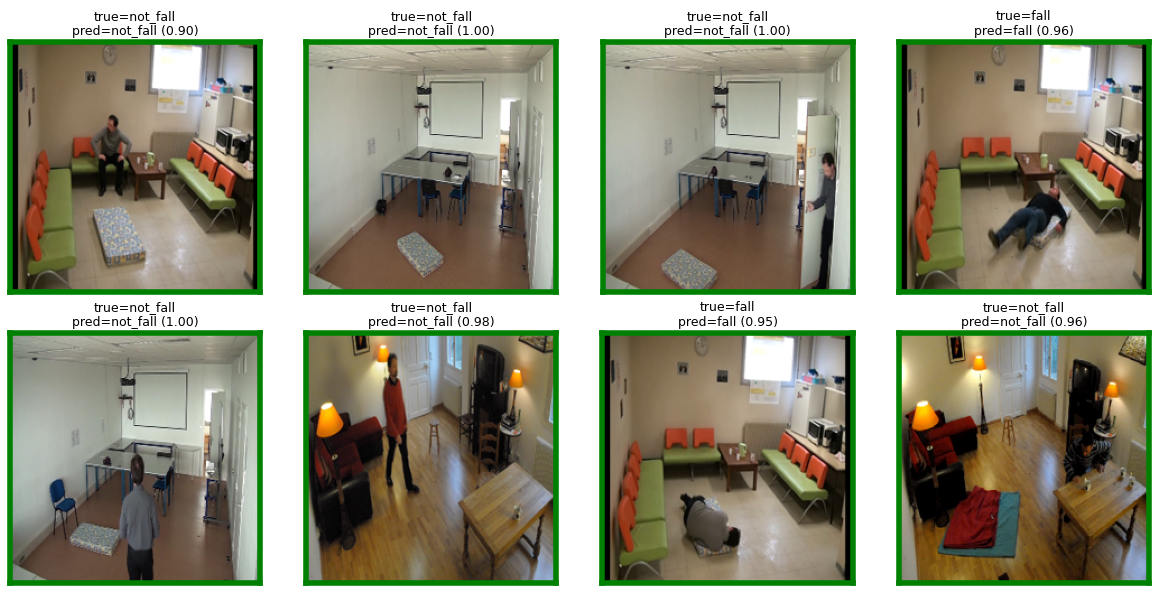

In [28]:
def show_prediction_gallery(samples_df, y_true, y_pred, probs, config, n=8):
    idxs = random.sample(range(len(samples_df)), min(n, len(samples_df)))
    fig, axes = plt.subplots(2, (len(idxs) + 1) // 2, figsize=(3 * ((len(idxs) + 1) // 2), 6))
    axes = axes.flatten()
    for ax, i in zip(axes, idxs):
        row = samples_df.iloc[i]
        frames = read_frames_quick(row["path"], (config["IMG_SIZE"], config["IMG_SIZE"]), config["MAX_FRAMES"])
        idx = pick_frame_start(len(frames), row["window"], row["margin"], row["label"], need=1) if frames else 0
        img = frames[idx] if frames else np.zeros((config["IMG_SIZE"], config["IMG_SIZE"], 3), dtype=np.uint8)

        correct = y_true[i] == y_pred[i]
        label_names = ["not_fall", "fall"]
        ax.imshow(img)
        for spine in ax.spines.values():
            spine.set_edgecolor("green" if correct else "red"); spine.set_linewidth(4)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"true={label_names[y_true[i]]}\npred={label_names[y_pred[i]]} ({probs[i].max():.2f})",
                     fontsize=9)
    for ax in axes[len(idxs):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_prediction_gallery(val_samples_df, y_true, y_pred, all_probs, CONFIG, n=8)

## 16. Inférence sur une nouvelle vidéo (avec visualisation)

In [36]:
@torch.no_grad()
def predict_video(video_path, spatial_model, temporal_model, config, show=True):
    device = config["DEVICE"]
    size = (config["IMG_SIZE"], config["IMG_SIZE"])
    frames = read_frames(video_path, resize=size, max_frames=config["MAX_FRAMES"])
    while len(frames) < config["L"] + 1:
        frames = frames * 2

    mid = len(frames) // 2
    img = spatial_transform(frames[mid]).unsqueeze(0).to(device)

    start = max(0, mid - config["L"] // 2)
    start = min(start, len(frames) - config["L"] - 1)
    flow_stack = compute_flow_stack(frames, start, config["L"], size)
    flow = torch.from_numpy(flow_stack).unsqueeze(0).to(device)

    prob_s = torch.softmax(spatial_model(img), dim=1)
    prob_t = torch.softmax(temporal_model(flow), dim=1)
    fused = (prob_s + prob_t) / 2

    label = "FALL" if fused.argmax(1).item() == 1 else "no fall"
    conf = fused.max().item()
    print(f"{video_path} -> {label}  (confidence={conf:.2f})")

    if show:
        dx, dy = flow_stack[0], flow_stack[1]
        fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
        axes[0].imshow(frames[mid]); axes[0].set_title("sampled frame"); axes[0].axis("off")
        axes[1].imshow(flow_to_color(dx * 20, dy * 20)); axes[1].set_title("optical flow"); axes[1].axis("off")
        fig.suptitle(f"Prediction: {label} (confidence={conf:.2f})")
        plt.tight_layout(); plt.show()
    return label


/kaggle/input/datasets/tuyenldvn/falldataset-imvia/Lecture_room/Lecture room/video (4).avi -> no fall  (confidence=1.00)


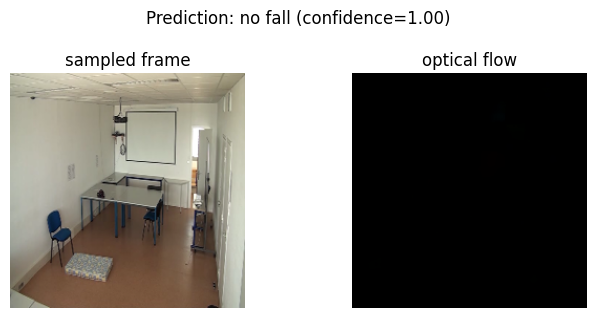

'no fall'

In [37]:
predict_video(val_videos_df.iloc[0]['path'], spatial_model, temporal_model, CONFIG)